HARRY GRAY 75% MODEL TRAINING:


Final Version:

Loading data
Starting with 16 threads to process 32 files.
Processing JSON_TO_CSV\45.csv (5715 rows)
Processing JSON_TO_CSV\4c.csv (5629 rows)
Processing JSON_TO_CSV\4a.csv (5790 rows)
Processing JSON_TO_CSV\43.csv (5724 rows)
Processing JSON_TO_CSV\49.csv (5645 rows)
Processing JSON_TO_CSV\4f.csv (5668 rows)
Processing JSON_TO_CSV\48.csv (5616 rows)
Processing JSON_TO_CSV\4b.csv (5714 rows)
Processing JSON_TO_CSV\44.csv (5826 rows)
Processing JSON_TO_CSV\4e.csv (5815 rows)
Processing JSON_TO_CSV\47.csv (5687 rows)
Processing JSON_TO_CSV\42.csv (5634 rows)
Processing JSON_TO_CSV\46.csv (5705 rows)
Processing JSON_TO_CSV\41.csv (5748 rows)
Processing JSON_TO_CSV\40.csv (5726 rows)
Processing JSON_TO_CSV\4d.csv (5664 rows)
Processing JSON_TO_CSV\51.csv (5616 rows)
Processing JSON_TO_CSV\50.csv (5637 rows)
Processing JSON_TO_CSV\55.csv (5765 rows)
Processing JSON_TO_CSV\52.csv (5701 rows)
Processing JSON_TO_CSV\5b.csv (5783 rows)
Processing JSON_TO_CSV\54.csv (5695 rows)
Processing JSON_T

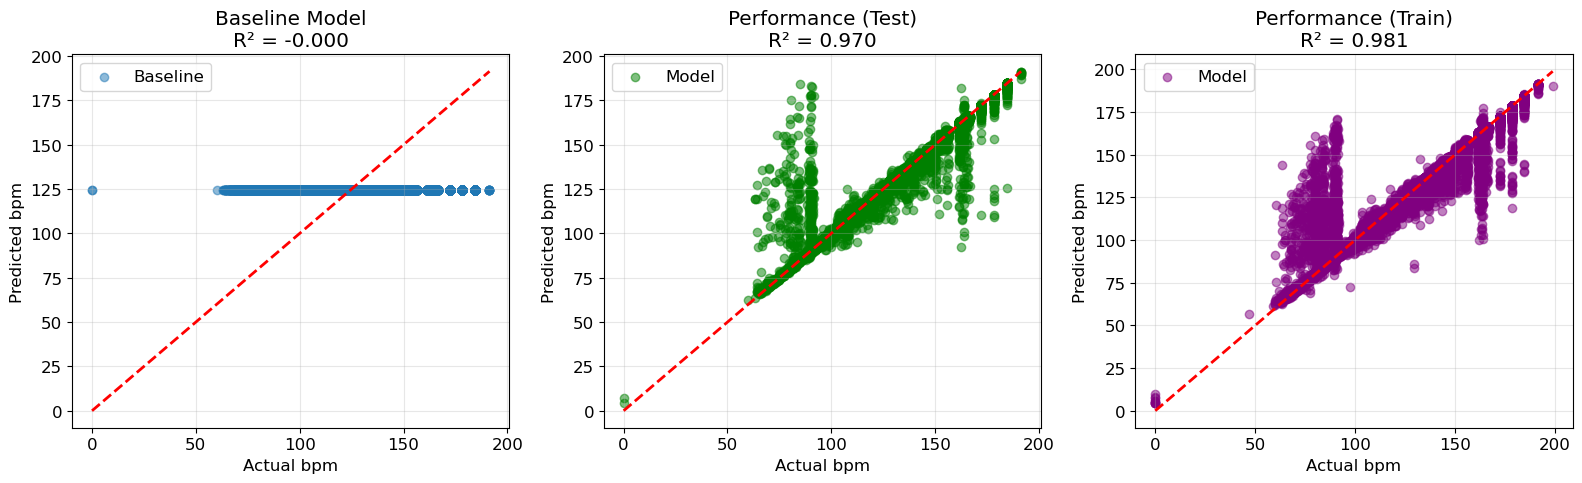

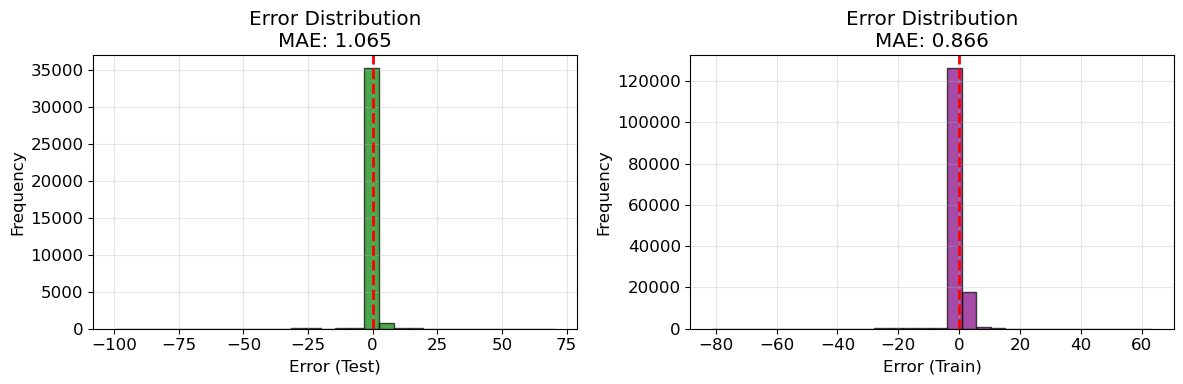

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import ast
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import matplotlib.pyplot as plt


#Config

DATA_DIR = "JSON_TO_CSV"
THREADS = 16
RS = 42

# Model Config
EST = 500
MXDEPTH=15
MIN_SMPLSPLIT=5
MIN_SMPLLEAF=3
MXFEATURE ='sqrt'

FEATURES = {
    "onset_rate": ["onset_rate"],
    "beats_count": ["beats_count"],
    "bpm": ["bpm"],
    "danceability": ["danceability"],
    "bpm_histogram_mean": ["bpm_histogram_first_peak_bpm", "mean"],
    "bpm_histogram_first_peak_bpm": ["bpm_histogram_first_peak_bpm", "mean"],
    "bpm_histogram_second_peak_spread": ["bpm_histogram_second_peak_bpm", "mean"],
    "bpm_histogram_second_peak_weight": ["bpm_histogram_second_peak_bpm", "mean"],

}
TARGET_FEATURE = "bpm"

## Script Start

def nested(d, path):
    for key in path:
        if key not in d:
            return None
        d = d[key]
    return d

def parse_feild(value):
    if pd.isna(value):
        return None

    if isinstance(value, dict):
        return value

    try:
        return json.loads(value) ## # eval() isn't optimal
    except Exception:
        pass

    try:
        value = ast.literal_eval(value) #fallback 
        if isinstance(value, dict):
            return value
    except Exception:
        print(f"{value}")
        pass

    return None

def process_csv(path):
    try: #attempted manual opening of files but pandas is better
        df = pd.read_csv(path)
    except Exception as e:  #added after seeing crashes debug
        print(f"{path}: {e}")
        return []

    results = []

    for val in df["rhythm"].dropna():
        rhythm_dict = parse_feild(val) #parsed inline changed to a function

        if rhythm_dict is None: #caused invalid rows before 
            continue

        row = []
        valid_row = True

        for feature_name, path in FEATURES.items(): 
            v = nested(rhythm_dict, path)

            if v is None: # help's during debugging
                print(f"Missing: {feature_name}")
                valid_row = False
                break

            try:
                row.append(float(v))
            except Exception: #allowed failure before now invalidates the row
                valid_row = False
                break

        if valid_row: # prevents duplicates
            results.append(row)

    return results

    
def load_all_csvs_threaded(data_dir):
    csv_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".csv")] ## directory based loading
    all_records = [] #per-file results now just appended

    print(f"Starting with {THREADS} threads to process {len(csv_files)} files.") # debug info for threading and csv files
    with ThreadPoolExecutor(max_workers=THREADS) as executor:
        future_to_file = {executor.submit(process_csv, f): f for f in csv_files}

        for future in as_completed(future_to_file):
            f = future_to_file[future]
            try:
                data = future.result()
                all_records.extend(data) #flattened after model ingestion
                print(f"Processing {f} ({len(data)} rows)") # progressing info 
            except Exception: #log removed beacuse everything is logged before this stage so why log
                pass 

    df = pd.DataFrame(all_records, columns=FEATURES.keys()) # moved to the end, this caused problems
    return df


def evaluate_model(model, X_train, X_test, y_train, y_test):
    baseline_model = DummyRegressor(strategy='mean') ##.fit(X_train, y_train)
    baseline_model.fit(X_train, y_train) # was unsure
    
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    baseline_predictions = baseline_model.predict(X_test)
    
    baseline = {}
    baseline['mae'] = mean_absolute_error(y_test, baseline_predictions)
    baseline['rmse'] = root_mean_squared_error(y_test, baseline_predictions)
    baseline['r2'] = r2_score(y_test, baseline_predictions)
    
    results = {}
    results['mae'] = mean_absolute_error(y_test, test_predictions)
    results['rmse'] = root_mean_squared_error(y_test, test_predictions)
    results['r2'] = r2_score(y_test, test_predictions)
    
    train_results = {}
    train_results['mae'] = mean_absolute_error(y_train, train_predictions)
    train_results['rmse'] = root_mean_squared_error(y_train, train_predictions)
    train_results['r2'] = r2_score(y_train, train_predictions)
    
    print("\n")
    print("Baseline - Test - Train")
    for metric in ['mae', 'rmse', 'r2']:
        print(f'{metric.upper():8s} Baseline: {baseline[metric]:6.3f}  Test: {results[metric]:6.3f}  Train: {train_results[metric]:6.3f}')
    
    plt.figure(figsize=(16, 5))
    plt.rcParams['font.size'] = 12
    
    plt.subplot(1, 3, 1)
    plt.scatter(y_test, baseline_predictions, alpha=0.5, label='Baseline')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel(f'Actual {TARGET_FEATURE}')
    plt.ylabel(f'Predicted {TARGET_FEATURE}')
    plt.title(f'Baseline Model\nR² = {baseline["r2"]:.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.scatter(y_test, test_predictions, alpha=0.5, label='Model', color='green')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel(f'Actual {TARGET_FEATURE}')
    plt.ylabel(f'Predicted {TARGET_FEATURE}')
    plt.title(f'Performance (Test)\nR² = {results["r2"]:.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    plt.scatter(y_train, train_predictions, alpha=0.5, label='Model', color='purple')
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    plt.xlabel(f'Actual {TARGET_FEATURE}')
    plt.ylabel(f'Predicted {TARGET_FEATURE}')
    plt.title(f'Performance (Train)\nR² = {train_results["r2"]:.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    test_residuals = y_test - test_predictions
    train_residuals = y_train - train_predictions
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(test_residuals, bins=30, alpha=0.7, color='green', edgecolor='black')
    plt.xlabel('Error (Test)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution\nMAE: {results["mae"]:.3f}')
    plt.axvline(0, color='red', linestyle='--', linewidth=2)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(train_residuals, bins=30, alpha=0.7, color='purple', edgecolor='black')
    plt.xlabel('Error (Train)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution\nMAE: {train_results["mae"]:.3f}')
    plt.axvline(0, color='red', linestyle='--', linewidth=2)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results, train_results, baseline

def main():
    print("Loading data")
    df = load_all_csvs_threaded(DATA_DIR)

    if df.empty:
        print("No rhythm data found, Fix it")
        return

    print(f"\n Loaded total {len(df)} rows")
    print(df.head())

    X = df.drop(columns=[TARGET_FEATURE]) #so it doesnt train on target feature.
    y = df[TARGET_FEATURE]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RS
    ) # 80 / 20 split, 0.2 is test size and 0.8 is train size

    print("\nTraining Random Forest")
    model = RandomForestRegressor(
        n_estimators=EST,
        max_depth=MXDEPTH,
        min_samples_split=MIN_SMPLSPLIT,
        min_samples_leaf=MIN_SMPLLEAF,
        max_features=MXFEATURE,
        random_state=RS,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    evaluate_model(model, X_train, X_test, y_train, y_test)

if __name__ == "__main__":
    main()